In [1]:
import pandas as pd
file_path="timedata.csv"
df=pd.read_csv(file_path)
print(df.head())


   Timespan (Mins)  \
0              NaN   
1            210.0   
2              NaN   
3            210.0   
4              NaN   

  Cloud Info - (Timestamp,(lat,lon, angle, area (sq.km), axis (km),eccentricity,distance,Duration,Velocity,MaxOverlap1)  \
0                                                NaN                                                                      
1  ('13-07-2016 00:15', [7.0, 73.8], 137.4, 16475...                                                                      
2                                                NaN                                                                      
3  ('13-07-2016 00:15', [9.5, 97.4], 64.2, 15473....                                                                      
4                                                NaN                                                                      

  Cloud Info - (Timestamp,(lat,lon, angle, area (sq.km), axis (km),eccentricity,distance,Duration,Velocity,MaxOverlap1).1  \
0  

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 89 columns):
 #   Column                                                                                                                    Non-Null Count  Dtype  
---  ------                                                                                                                    --------------  -----  
 0   Timespan (Mins)                                                                                                           110 non-null    float64
 1   Cloud Info - (Timestamp,(lat,lon, angle, area (sq.km), axis (km),eccentricity,distance,Duration,Velocity,MaxOverlap1)     110 non-null    object 
 2   Cloud Info - (Timestamp,(lat,lon, angle, area (sq.km), axis (km),eccentricity,distance,Duration,Velocity,MaxOverlap1).1   110 non-null    object 
 3   Cloud Info - (Timestamp,(lat,lon, angle, area (sq.km), axis (km),eccentricity,distance,Duration,Velocity,MaxOverlap1).2   110 non-null 

In [3]:
import pandas as pd
import numpy as np
cloud_cols = [col for col in df.columns if "Cloud Info" in col]

df_long = df.melt(
    id_vars=["Timespan (Mins)"],
    value_vars=cloud_cols,
    var_name="cloud_step",
    value_name="cloud_data"
)

# Remove empty rows
df_long = df_long.dropna(subset=["cloud_data"])
print(cloud_cols)

['Cloud Info - (Timestamp,(lat,lon, angle, area (sq.km), axis (km),eccentricity,distance,Duration,Velocity,MaxOverlap1)', 'Cloud Info - (Timestamp,(lat,lon, angle, area (sq.km), axis (km),eccentricity,distance,Duration,Velocity,MaxOverlap1).1', 'Cloud Info - (Timestamp,(lat,lon, angle, area (sq.km), axis (km),eccentricity,distance,Duration,Velocity,MaxOverlap1).2', 'Cloud Info - (Timestamp,(lat,lon, angle, area (sq.km), axis (km),eccentricity,distance,Duration,Velocity,MaxOverlap1).3', 'Cloud Info - (Timestamp,(lat,lon, angle, area (sq.km), axis (km),eccentricity,distance,Duration,Velocity,MaxOverlap1).4', 'Cloud Info - (Timestamp,(lat,lon, angle, area (sq.km), axis (km),eccentricity,distance,Duration,Velocity,MaxOverlap1).5', 'Cloud Info - (Timestamp,(lat,lon, angle, area (sq.km), axis (km),eccentricity,distance,Duration,Velocity,MaxOverlap1).6', 'Cloud Info - (Timestamp,(lat,lon, angle, area (sq.km), axis (km),eccentricity,distance,Duration,Velocity,MaxOverlap1).7', 'Cloud Info - (Ti

In [8]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1649 entries, 1 to 4163
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Timespan (Mins)  1649 non-null   float64       
 1   cloud_step       1649 non-null   object        
 2   cloud_data       1649 non-null   object        
 3   timestamp        1649 non-null   datetime64[ns]
 4   lat              1649 non-null   float64       
 5   lon              1649 non-null   float64       
 6   angle            1649 non-null   float64       
 7   area             1649 non-null   float64       
 8   axis1            1649 non-null   float64       
 9   axis2            1649 non-null   float64       
 10  ecc              1649 non-null   float64       
 11  distance         1649 non-null   float64       
 12  duration         1649 non-null   float64       
 13  velocity         1649 non-null   float64       
 14  overlap          1649 non-null   float64     

In [4]:
import ast

s = "('13-07-2016 00:15', [7.0, 73.8], 137.4)"
parsed = ast.literal_eval(s)

print(parsed)

('13-07-2016 00:15', [7.0, 73.8], 137.4)


In [5]:
import ast

def parse_cloud(row):
    parsed = ast.literal_eval(row)

    timestamp = parsed[0]
    lat = parsed[1][0]
    lon = parsed[1][1]
    angle = parsed[2]
    area = parsed[3]
    axis1 = parsed[4][0]
    axis2 = parsed[4][1]
    ecc = parsed[5]
    distance = parsed[6]
    duration = parsed[7]
    velocity = parsed[8]
    overlap = parsed[9]

    return pd.Series([
        timestamp, lat, lon, angle, area,
        axis1, axis2, ecc, distance,
        duration, velocity, overlap
    ])

df_long[[
    "timestamp","lat","lon","angle","area",
    "axis1","axis2","ecc",
    "distance","duration","velocity","overlap"
]] = df_long["cloud_data"].apply(parse_cloud)

In [6]:
df_long["timestamp"] = pd.to_datetime(df_long["timestamp"], dayfirst=True)
df_long = df_long.sort_values("timestamp")

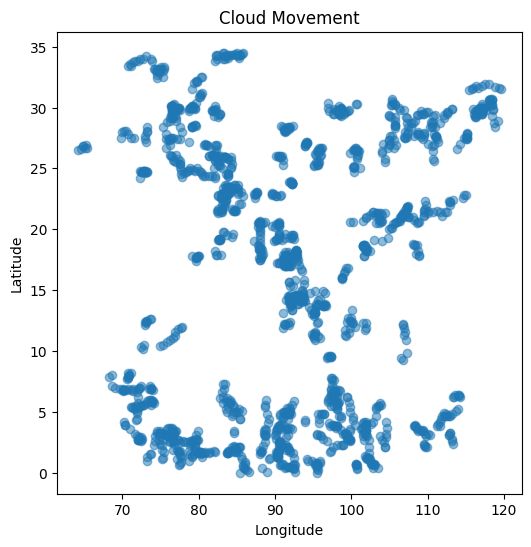

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(df_long["lon"], df_long["lat"], alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Cloud Movement")
plt.show()